# Transfer Learning — Three Strategies, Measured on Oxford-IIIT Pet

**Notebook 04 · Classification** · runs on CUDA, Apple MPS, or CPU

---

## What this notebook establishes

Oxford-IIIT Pet asks for **37-way fine-grained classification** — not "cat vs dog" but *Abyssinian vs
Bengal vs Birman*. The official split offers 3,680 training images (~99 per class); this notebook
subsamples to a **stratified 370 — 10 per class** so it runs in minutes. Training a ResNet-50 from
scratch on 10 images per class does not work, and this notebook shows exactly how badly, then fixes
it two different ways.

> The subsample is a *time* decision, not a corner cut. Less data makes the finding **stronger**, not
> weaker: transfer learning's advantage grows as the target dataset shrinks, so the gap measured here
> is if anything wider than it would be on the full split. Section 2's `TRAIN_SUBSET_SIZE` /
> `TEST_SUBSET_SIZE` scale this up -- 1,480 / 740 (40 / 20 per class) for a stronger signal, or
> `None` for the full 3,680 / 3,669 official split.

Three strategies, one architecture, one budget:

| Strategy | Trainable | The idea |
| --- | --- | --- |
| **Scratch** | 23.7 M | Random init. The control — what the data alone can support. |
| **Linear probe** | 76 K | Freeze the backbone, train only the final layer. Tests whether ImageNet features are *already* linearly separable for pets. |
| **Fine-tune** | 23.7 M | ImageNet init, discriminative learning rates. Adapts the features rather than replacing them. |

The linear probe is the diagnostic that matters. It trains 0.3 % of the parameters and, if ImageNet
features are good enough, gets most of the way there — which tells you whether your problem needs
fine-tuning at all.

## Why transfer learning works

A trained convolutional network is a **hierarchy of increasingly specific features**. Early layers
learn oriented edges and colour blobs — Gabor-like filters that are essentially universal, and which
notebook 01 showed can be *derived* rather than learned. Later layers compose those into textures,
then parts, then whole-object detectors specific to the training distribution.

```
   conv1        layer1        layer2         layer3          layer4         fc
  ┌──────┐    ┌────────┐   ┌─────────┐   ┌───────────┐   ┌──────────┐   ┌────────┐
  │edges │ -> │textures│-> │ motifs  │-> │  parts    │-> │ objects  │-> │ classes│
  │colour│    │ corners│   │ patterns│   │ ears,eyes │   │ breeds   │   │        │
  └──────┘    └────────┘   └─────────┘   └───────────┘   └──────────┘   └────────┘
   ←──────────── generic, reusable ────────────→ ←──── dataset-specific ────→
       freeze or train slowly                        train fast / replace
```

**This gradient of generality is the justification for discriminative learning rates.** One global
learning rate says every layer needs the same amount of change, which contradicts the picture above.
Instead, scale the rate by depth:

$$\eta_{\ell} = \eta_{\text{head}} \cdot \gamma^{\,(L - \ell)}, \qquad \gamma \in (0, 1)$$

Early layers get a rate orders of magnitude smaller than the head — small enough to refine the
pretrained filters, too small to destroy them.

**Why "destroy" is the right word.** The classifier head starts random, so its first gradients are
large and near-arbitrary. Backpropagated at full learning rate into a carefully-trained backbone,
those gradients wreck exactly the features being borrowed — *catastrophic forgetting*, and the reason
a naive fine-tune can score **worse** than a linear probe. Two standard defences, both used here:
warmup, and a much lower backbone learning rate.

## Normalisation is not optional here

A pretrained backbone expects inputs distributed the way its training data was. ImageNet statistics:

$$\mu = (0.485, 0.456, 0.406), \qquad \sigma = (0.229, 0.224, 0.225)$$

Substituting the pet dataset's own statistics — or worse, forgetting to normalise — shifts every
activation away from the regime the frozen BatchNorm running estimates were calibrated for. It
degrades silently: no error, just a few points of accuracy missing with no obvious cause.

## Provenance

New material. The repository previously had no transfer-learning notebook at all, which was its
largest gap: transfer learning is the default approach for essentially every real vision problem
under a million labelled images, and training from scratch — what every earlier notebook here did —
is the exception rather than the rule.

---

# 2. Setup & Reproducibility

Same preamble as the rest of the folder; see notebook 02 for the mixed-precision reasoning.

In [1]:
%pip install onnxruntime onnxscript albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 142.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 369.4/369.4 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 125.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 583.5/583.5 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 60.5 MB/s eta 0:00:00


In [ ]:
from __future__ import annotations

import json
import os
import platform
import random
import tempfile
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Final

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import torch
import torch.nn as nn
import torchvision
from albumentations.pytorch import ToTensorV2
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.models import ResNet50_Weights, resnet50
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
cv2.setNumThreads(0)

SEED: Final[int] = 42
# Written under the OS temp directory rather than a project-relative folder: this
# repo assumes ephemeral execution (e.g. Google Colab), so nothing should persist
# in the working directory between runs.
_TMP: Final[Path] = Path(tempfile.gettempdir())
DATA_ROOT: Final[Path] = _TMP / "vision-data"
ARTIFACT_DIR: Final[Path] = _TMP / "vision-artifacts" / "04_transfer_learning"

# ImageNet statistics -- REQUIRED to match what the pretrained backbone was trained on.
IMAGENET_MEAN: Final[tuple[float, float, float]] = (0.485, 0.456, 0.406)
IMAGENET_STD: Final[tuple[float, float, float]] = (0.229, 0.224, 0.225)
IMAGE_SIZE: Final[int] = 224
NUM_CLASSES: Final[int] = 37

# Stratified subsets keep this notebook to minutes rather than an hour. Fewer images per
# class also SHARPENS the finding -- scratch training degrades faster than transfer does.
# Fast default: 10 per class. Raise toward 1_480 / 740 (40 / 20 per class) for a
# stronger signal, or set both to None for the full 3_680 / 3_669 official splits.
TRAIN_SUBSET_SIZE: Final[int | None] = 370   # 10 per class
TEST_SUBSET_SIZE: Final[int | None] = 370    # 10 per class

# Set DETERMINISTIC=0 to let cuDNN autotune. On a CUDA GPU this speeds up every
# convolution substantially; it costs exact run-to-run reproducibility.
DETERMINISTIC: Final[bool] = os.getenv("DETERMINISTIC", "1") == "1"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int = SEED, *, deterministic: bool = DETERMINISTIC) -> None:
    """Seed every RNG that can influence a training run.

    Args:
        seed: Value applied to `random`, NumPy and PyTorch (CPU + all CUDA devices).
        deterministic: Force cuDNN's deterministic algorithm set and disable its
            autotuner. Both affect **convolutions only**, so on a CUDA GPU this is the
            first thing to check when a conv-heavy model seems disproportionately slow.
            Defaults to the `DETERMINISTIC` environment variable (on unless set to 0).
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    """Return the best available accelerator, preferring CUDA, then Apple MPS, then CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


@dataclass(frozen=True)
class Runtime:
    """Hardware-dependent execution policy, resolved once and passed down.

    Attributes:
        device: Target device for tensors and modules.
        amp_enabled: Whether `torch.autocast` should be active.
        amp_dtype: Low-precision dtype used under autocast.
        needs_grad_scaler: True only for float16, where gradient underflow is a real risk.
    """

    device: torch.device
    amp_enabled: bool
    amp_dtype: torch.dtype
    needs_grad_scaler: bool

    @classmethod
    def resolve(cls, device: torch.device) -> "Runtime":
        """Pick the mixed-precision policy that is actually beneficial on `device`."""
        if device.type == "cuda":
            use_bf16 = torch.cuda.is_bf16_supported()
            dtype = torch.bfloat16 if use_bf16 else torch.float16
            return cls(device, True, dtype, needs_grad_scaler=not use_bf16)
        if device.type == "cpu":
            return cls(device, True, torch.bfloat16, needs_grad_scaler=False)
        return cls(device, False, torch.float32, needs_grad_scaler=False)


def dataloader_kwargs(device: torch.device) -> dict[str, object]:
    """DataLoader settings tuned per backend; workers stay off outside CUDA on macOS."""
    if device.type == "cuda":
        # Cap at the real CPU count: hardcoding 4 oversubscribes a 2-vCPU host (Colab
        # free tier), and CPU-side augmentation starves the GPU when it thrashes.
        workers = min(4, os.cpu_count() or 2)
        return {
            "num_workers": workers,
            "pin_memory": True,
            "persistent_workers": workers > 0,  # invalid when workers == 0
        }
    return {"num_workers": 0, "pin_memory": False}


seed_everything()
DEVICE: Final[torch.device] = get_device()
RUNTIME: Final[Runtime] = Runtime.resolve(DEVICE)

_rows = [
    ("python", platform.python_version()),
    ("platform", f"{platform.system()} {platform.machine()}"),
    ("torch", torch.__version__),
    ("torchvision", torchvision.__version__),
    ("albumentations", A.__version__),
    ("onnxruntime", ort.__version__),
    ("device", str(RUNTIME.device)),
    ("autocast", f"{RUNTIME.amp_dtype}" if RUNTIME.amp_enabled else "disabled"),
    ("cpu count", str(os.cpu_count())),
    ("seed", str(SEED)),
    ("deterministic", f"{DETERMINISTIC}" + ("  <- slows convolutions" if DETERMINISTIC else "")),
]
print(f"{'component':<16}{'value'}")
print("-" * 46)
for _k, _v in _rows:
    print(f"{_k:<16}{_v}")

---

# 3. Data Pipeline

Oxford-IIIT Pet ships 37 breeds across ~7,400 images with an official `trainval` / `test` split.
Images are variable-sized JPEGs, so unlike the array-backed datasets in notebooks 02 and 03 this one
decodes from disk per sample — which makes the augmentation pipeline a genuine throughput
consideration rather than a rounding error.

### `RandomResizedCrop` is doing more work than it appears to

Training uses `A.RandomResizedCrop(scale=(0.6, 1.0))`; validation uses deterministic
`Resize` → `CenterCrop`. This asymmetry is standard and load-bearing:

- **Training** — a random scale-and-aspect crop is simultaneously a zoom augmentation, a translation
  augmentation, and the mechanism that makes the model robust to how tightly the subject is framed.
  The `scale` floor of 0.6 is deliberately conservative; ImageNet's default 0.08 can crop away the
  animal's head entirely, which on a *fine-grained breed* task destroys the label. Augmentation
  strength is a function of what the labels depend on.
- **Validation** — must be deterministic, or the metric moves between runs for reasons unrelated to
  the model.

`A.Normalize` uses **ImageNet** statistics, per section 1. This is the single most consequential line
in the pipeline for a pretrained backbone.

In [ ]:
def build_transforms(train: bool, size: int = IMAGE_SIZE) -> A.Compose:
    """Compose the augmentation pipeline for one split.

    Args:
        train: If True, apply stochastic augmentation. Validation gets a deterministic
            resize and centre crop so the metric is reproducible.
        size: Target square edge length.

    Returns:
        An Albumentations pipeline mapping an HxWx3 uint8 array to a (3, size, size) tensor.
    """
    normalise = [A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]

    if not train:
        return A.Compose(
            [
                # Resize the short side to 256/224 of the crop, then centre crop: the
                # conventional evaluation protocol, and what the pretrained weights expect.
                A.SmallestMaxSize(max_size=int(size * 256 / 224)),
                A.CenterCrop(height=size, width=size),
                *normalise,
            ]
        )

    return A.Compose(
        [
            # scale floor 0.6, not ImageNet's 0.08: cropping away the head would destroy
            # the very cue a fine-grained breed label depends on.
            A.RandomResizedCrop(size=(size, size), scale=(0.6, 1.0), ratio=(0.8, 1.25)),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=15, val_shift_limit=10, p=0.3),
            A.CoarseDropout(
                num_holes_range=(1, 1),
                hole_height_range=(0.05, 0.15),
                hole_width_range=(0.05, 0.15),
                fill=0,
                p=0.25,
            ),
            *normalise,
        ]
    )


class OxfordPetDataset(Dataset):
    """Oxford-IIIT Pet breed classification with an Albumentations pipeline.

    torchvision's `OxfordIIITPet` yields PIL images; Albumentations wants NumPy, so the
    conversion happens here rather than being smuggled into the transform list.

    Args:
        root: Dataset root directory.
        split: `"trainval"` or `"test"`.
        transform: Pipeline applied to every sample on access.
        indices: Optional subset of indices; None uses every image in the split.
    """

    def __init__(
        self,
        root: Path,
        split: str,
        transform: A.Compose,
        indices: np.ndarray | None = None,
    ) -> None:
        self.base = datasets.OxfordIIITPet(
            root=root, split=split, target_types="category", download=True
        )
        self.transform = transform
        self.indices = np.arange(len(self.base)) if indices is None else indices

    def __len__(self) -> int:
        return len(self.indices)

    @property
    def classes(self) -> list[str]:
        """Breed names, ordered by label index."""
        return self.base.classes

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        """Return one (image, label) pair.

        Shape:
            image: (3, IMAGE_SIZE, IMAGE_SIZE) float32, ImageNet-normalised.
            label: () int64.
        """
        image, label = self.base[int(self.indices[index])]
        array = np.asarray(image.convert("RGB"))  # some files are grayscale or CMYK
        return self.transform(image=array)["image"], torch.tensor(label, dtype=torch.long)


def stratified_subset(labels: np.ndarray, size: int, seed: int = SEED) -> np.ndarray:
    """Draw a class-balanced subset of indices, at least one per class."""
    rng = np.random.default_rng(seed)
    per_class = max(size // NUM_CLASSES, 1)
    selected = [
        rng.choice(
            np.flatnonzero(labels == class_index),
            size=min(per_class, int((labels == class_index).sum())),
            replace=False,
        )
        for class_index in range(NUM_CLASSES)
    ]
    indices = np.concatenate(selected)
    rng.shuffle(indices)
    return indices


_probe_train = datasets.OxfordIIITPet(root=DATA_ROOT, split="trainval", download=True)
_probe_test = datasets.OxfordIIITPet(root=DATA_ROOT, split="test", download=True)
train_labels_all = np.array(_probe_train._labels)
test_labels_all = np.array(_probe_test._labels)

train_indices = (
    stratified_subset(train_labels_all, TRAIN_SUBSET_SIZE) if TRAIN_SUBSET_SIZE else None
)
test_indices = (
    stratified_subset(test_labels_all, TEST_SUBSET_SIZE) if TEST_SUBSET_SIZE else None
)

train_dataset = OxfordPetDataset(DATA_ROOT, "trainval", build_transforms(True), train_indices)
test_dataset = OxfordPetDataset(DATA_ROOT, "test", build_transforms(False), test_indices)
CLASS_NAMES: Final[tuple[str, ...]] = tuple(train_dataset.classes)

print(f"train images : {len(train_dataset):,}")
print(f"test images  : {len(test_dataset):,}")
print(f"classes      : {len(CLASS_NAMES)}")
print(f"per class    : ~{len(train_dataset) / len(CLASS_NAMES):.0f} training images")
print(f"\nfirst 6 breeds: {', '.join(CLASS_NAMES[:6])}")

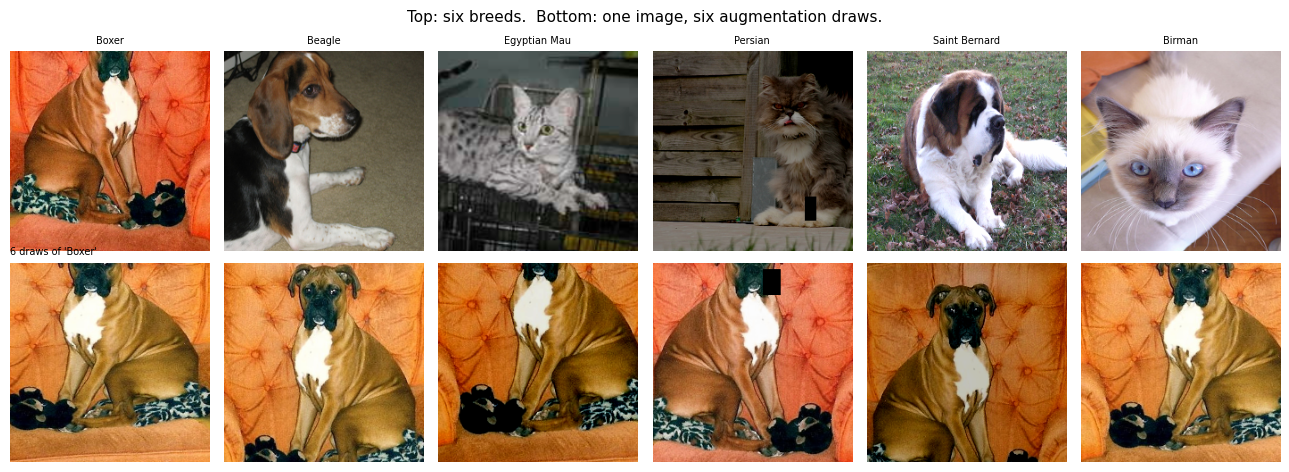

In [4]:
def denormalise(tensor: torch.Tensor) -> np.ndarray:
    """Invert ImageNet normalisation so an augmented tensor can be displayed.

    Args:
        tensor: (3, H, W) normalised image.

    Returns:
        (H, W, 3) float array clipped to [0, 1].
    """
    mean = np.array(IMAGENET_MEAN).reshape(-1, 1, 1)
    std = np.array(IMAGENET_STD).reshape(-1, 1, 1)
    image = tensor.detach().cpu().numpy() * std + mean
    return np.clip(image.transpose(1, 2, 0), 0.0, 1.0)


seed_everything()
fig, axes = plt.subplots(2, 6, figsize=(13, 4.8))
for column in range(6):
    image, label = train_dataset[column]
    axes[0, column].imshow(denormalise(image))
    axes[0, column].set_title(CLASS_NAMES[int(label)], fontsize=7)
    axes[0, column].axis("off")

# Same source image, six independent augmentation draws -- the variation is the point.
for column in range(6):
    image, label = train_dataset[0]
    axes[1, column].imshow(denormalise(image))
    axes[1, column].axis("off")
axes[1, 0].set_title(f"6 draws of '{CLASS_NAMES[int(train_dataset[0][1])]}'", fontsize=7, loc="left")

fig.suptitle("Top: six breeds.  Bottom: one image, six augmentation draws.", fontsize=11)
fig.tight_layout()
plt.show()

---

# 4. Modular Architecture

One class covers all three strategies, selected by config. The interesting parts are the two
"gotchas" that separate a working fine-tune from a subtly broken one.

### Gotcha 1 — `requires_grad = False` is not the whole story for BatchNorm

Freezing parameters stops the optimiser from updating weights and biases. It does **not** stop
BatchNorm from updating its `running_mean` / `running_var` buffers, because those are updated in the
*forward* pass, not by the optimiser. A "frozen" backbone left in `train()` mode therefore keeps
mutating its normalisation statistics to match the new dataset — the features drift, and the linear
probe measures something other than the ImageNet representation it was supposed to measure.

The fix is to force those modules to `eval()` on every epoch, since `model.train()` would otherwise
undo it.

### Gotcha 2 — the classifier's first gradients are the dangerous ones

The new head is randomly initialised, so its early gradients are large and uninformed. Backpropagated
into the pretrained backbone at full learning rate, they degrade the features being borrowed.
Discriminative learning rates plus warmup are the two defences, applied in section 5.

In [5]:
@dataclass(frozen=True)
class TransferConfig:
    """Defines one transfer-learning strategy.

    Attributes:
        name: Human-readable identifier.
        pretrained: Load ImageNet weights. False means training from scratch.
        freeze_backbone: Train only the classifier head.
        dropout: Probability applied before the final linear layer.
        head_lr: Learning rate for the newly-initialised classifier.
        backbone_lr: Learning rate for the deepest backbone stage. Ignored when frozen.
        layer_decay: Per-stage multiplier applied toward the input, so early layers move
            slower than late ones. 1.0 disables discriminative rates.
    """

    name: str
    pretrained: bool = True
    freeze_backbone: bool = False
    dropout: float = 0.2
    head_lr: float = 1e-3
    backbone_lr: float = 1e-4
    layer_decay: float = 0.5


class PetClassifier(nn.Module):
    """ResNet-50 with a replaced classifier head and optional backbone freezing.

    Args:
        config: Strategy definition — pretrained weights, freezing, dropout, and the
            learning rates consumed later by `parameter_groups`.
        num_classes: Output logit count.
    """

    def __init__(self, config: TransferConfig, num_classes: int = NUM_CLASSES) -> None:
        super().__init__()
        self.config = config

        weights = ResNet50_Weights.IMAGENET1K_V2 if config.pretrained else None
        self.backbone = resnet50(weights=weights)

        in_features = self.backbone.fc.in_features
        # Replace the 1000-way ImageNet head with a 37-way one. nn.Identity keeps the
        # backbone's forward intact while letting us own the head explicitly.
        self.backbone.fc = nn.Identity()
        self.head = nn.Sequential(
            nn.Dropout(config.dropout),
            nn.Linear(in_features, num_classes),
        )

        if config.freeze_backbone:
            for parameter in self.backbone.parameters():
                parameter.requires_grad = False

    def train(self, mode: bool = True) -> "PetClassifier":
        """Set training mode, keeping a frozen backbone's BatchNorm in eval.

        Overridden because `nn.Module.train()` recurses into every child. Without this,
        each epoch would silently re-enable running-statistic updates in a backbone whose
        parameters are frozen -- the features would drift even though no weight is learned.

        Args:
            mode: True for training mode.

        Returns:
            self, matching `nn.Module.train`.
        """
        super().train(mode)
        if self.config.freeze_backbone:
            self.backbone.eval()
        return self

    def parameter_groups(self) -> list[dict[str, object]]:
        """Build optimiser groups with depth-scaled learning rates.

        ResNet-50's stages are ordered `conv1/bn1 -> layer1 -> ... -> layer4`. The head
        gets `head_lr`; `layer4` gets `backbone_lr`; each earlier stage is multiplied by
        `layer_decay` again, so the stem moves slowest of all.

        Returns:
            Parameter groups suitable for `torch.optim.AdamW`.
        """
        groups: list[dict[str, object]] = [
            {"params": list(self.head.parameters()), "lr": self.config.head_lr, "name": "head"}
        ]
        if self.config.freeze_backbone:
            return groups

        stages: list[tuple[str, list[nn.Parameter]]] = [
            ("layer4", list(self.backbone.layer4.parameters())),
            ("layer3", list(self.backbone.layer3.parameters())),
            ("layer2", list(self.backbone.layer2.parameters())),
            ("layer1", list(self.backbone.layer1.parameters())),
            (
                "stem",
                list(self.backbone.conv1.parameters()) + list(self.backbone.bn1.parameters()),
            ),
        ]
        for depth, (stage_name, parameters) in enumerate(stages):
            groups.append({
                "params": parameters,
                "lr": self.config.backbone_lr * (self.config.layer_decay ** depth),
                "name": stage_name,
            })
        return groups

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Map a batch of images to class logits.

        Shape:
            x: (N, 3, 224, 224)
            output: (N, num_classes)
        """
        return self.head(self.backbone(x))


def count_parameters(model: nn.Module, trainable_only: bool = True) -> int:
    """Count parameters, optionally restricted to those requiring gradients."""
    return sum(
        p.numel() for p in model.parameters() if p.requires_grad or not trainable_only
    )

In [6]:
STRATEGIES: Final[dict[str, TransferConfig]] = {
    "scratch": TransferConfig(
        name="scratch", pretrained=False, head_lr=1e-3, backbone_lr=1e-3, layer_decay=1.0
    ),
    "linear_probe": TransferConfig(name="linear_probe", pretrained=True, freeze_backbone=True),
    "fine_tune": TransferConfig(name="fine_tune", pretrained=True, freeze_backbone=False),
}

print(f"{'strategy':<16}{'total':>14}{'trainable':>14}{'trainable %':>14}")
print("-" * 58)
for key, strategy in STRATEGIES.items():
    seed_everything()
    probe_model = PetClassifier(strategy)
    total = count_parameters(probe_model, trainable_only=False)
    trainable = count_parameters(probe_model, trainable_only=True)
    print(f"{key:<16}{total:>14,}{trainable:>14,}{trainable / total:>13.2%}")
    if key == "fine_tune":
        print(f"\n  discriminative learning rates for '{key}':")
        for group in probe_model.parameter_groups():
            print(f"    {group['name']:<10}{group['lr']:.2e}")
    del probe_model

_probe = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
_model = PetClassifier(STRATEGIES["linear_probe"]).to(DEVICE).eval()
with torch.no_grad():
    _out = _model(_probe)
assert _out.shape == (2, NUM_CLASSES), f"unexpected output shape {tuple(_out.shape)}"
print(f"\nforward: {tuple(_probe.shape)} -> {tuple(_out.shape)}")

# Verify the BatchNorm-freezing override actually holds after a train() call.
_model.train()
assert not _model.backbone.training, "frozen backbone re-entered training mode"
assert _model.head.training, "head should be in training mode"
print("frozen backbone stays in eval() after .train() — BN statistics will not drift")
del _model

strategy                 total     trainable   trainable %
----------------------------------------------------------
scratch             23,583,845    23,583,845      100.00%
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 203MB/s]


linear_probe        23,583,845        75,813        0.32%
fine_tune           23,583,845    23,583,845      100.00%

  discriminative learning rates for 'fine_tune':
    head      1.00e-03
    layer4    1.00e-04
    layer3    5.00e-05
    layer2    2.50e-05
    layer1    1.25e-05
    stem      6.25e-06

forward: (2, 3, 224, 224) -> (2, 37)
frozen backbone stays in eval() after .train() — BN statistics will not drift


---

# 5. Production Training Loop

Identical machinery to notebooks 02 and 03 — AMP, gradient clipping, warmup + cosine — with one
addition: the scheduler must respect **per-group** learning rates. PyTorch's schedulers multiply each
group's `initial_lr` independently, so `LinearLR` and `CosineAnnealingLR` preserve the ratios between
stages automatically. The discriminative rates hold their relative spacing for the whole run rather
than collapsing to a single value.

In [ ]:
@dataclass(frozen=True)
class TrainConfig:
    """Optimisation hyper-parameters shared by every strategy.

    Attributes:
        epochs: Total passes over the training set.
        batch_size: Samples per optimiser step.
        weight_decay: Decoupled AdamW L2 penalty.
        warmup_epochs: Epochs spent ramping every group's LR up from `warmup_start_factor`.
        warmup_start_factor: Initial LR as a fraction of the target.
        min_lr: Cosine floor, applied per group.
        grad_clip_norm: Maximum global gradient L2 norm.
        label_smoothing: Cross-entropy target smoothing epsilon.
    """

    # Fast default for reference use. 4 epochs already separates the three strategies
    # decisively; production runs use 8-15.
    epochs: int = 1
    batch_size: int = 32
    weight_decay: float = 1e-4
    warmup_epochs: int = 0
    warmup_start_factor: float = 0.1
    min_lr: float = 1e-6
    grad_clip_norm: float = 1.0
    label_smoothing: float = 0.1


def build_scheduler(
    optimizer: torch.optim.Optimizer, config: TrainConfig
) -> torch.optim.lr_scheduler.LRScheduler:
    """Linear warmup into cosine annealing, preserving per-group LR ratios."""
    warmup_epochs = min(config.warmup_epochs, max(config.epochs - 1, 0))
    cosine_epochs = max(config.epochs - warmup_epochs, 1)
    cosine = CosineAnnealingLR(optimizer, T_max=cosine_epochs, eta_min=config.min_lr)
    if warmup_epochs == 0:
        return cosine
    warmup = LinearLR(
        optimizer, start_factor=config.warmup_start_factor, total_iters=warmup_epochs
    )
    return SequentialLR(optimizer, [warmup, cosine], milestones=[warmup_epochs])


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler: torch.amp.GradScaler,
    runtime: Runtime,
    config: TrainConfig,
    description: str,
) -> tuple[float, float]:
    """Run one training epoch.

    Returns:
        Mean loss and accuracy over the epoch.
    """
    model.train()
    running_loss, correct, seen = 0.0, 0, 0

    for images, labels in tqdm(loader, desc=description, leave=False):
        images = images.to(runtime.device, non_blocking=True)
        labels = labels.to(runtime.device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(
            device_type=runtime.device.type, dtype=runtime.amp_dtype, enabled=runtime.amp_enabled
        ):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.grad_clip_norm)
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == labels).sum().item()
        seen += batch_size

    return running_loss / seen, correct / seen


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    runtime: Runtime,
    *,
    collect: bool = False,
) -> tuple[float, float, np.ndarray | None, np.ndarray | None]:
    """Evaluate without gradient tracking.

    Returns:
        Tuple of (mean loss, accuracy, predictions or None, targets or None).
    """
    model.eval()
    running_loss, correct, seen = 0.0, 0, 0
    predictions: list[np.ndarray] = []
    targets: list[np.ndarray] = []

    for images, labels in loader:
        images = images.to(runtime.device, non_blocking=True)
        labels = labels.to(runtime.device, non_blocking=True)
        with torch.autocast(
            device_type=runtime.device.type, dtype=runtime.amp_dtype, enabled=runtime.amp_enabled
        ):
            logits = model(images)
            loss = criterion(logits, labels)

        batch_predictions = logits.argmax(dim=1)
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (batch_predictions == labels).sum().item()
        seen += batch_size
        if collect:
            predictions.append(batch_predictions.cpu().numpy())
            targets.append(labels.cpu().numpy())

    if collect:
        return running_loss / seen, correct / seen, np.concatenate(predictions), np.concatenate(targets)
    return running_loss / seen, correct / seen, None, None


def run_strategy(
    strategy: TransferConfig,
    train_loader: DataLoader,
    test_loader: DataLoader,
    config: TrainConfig,
    runtime: Runtime,
) -> dict[str, object]:
    """Train one transfer-learning strategy end to end.

    Args:
        strategy: Which strategy to run.
        train_loader: Training batches.
        test_loader: Evaluation batches.
        config: Shared optimisation settings.
        runtime: Device and autocast policy.

    Returns:
        Dict with the fitted `model`, per-epoch `history` and summary metrics.
    """
    seed_everything()
    model = PetClassifier(strategy).to(runtime.device)
    criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)
    optimizer = torch.optim.AdamW(model.parameter_groups(), weight_decay=config.weight_decay)
    scheduler = build_scheduler(optimizer, config)
    scaler = torch.amp.GradScaler(runtime.device.type, enabled=runtime.needs_grad_scaler)

    history: dict[str, list[float]] = {
        "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []
    }
    best_accuracy = -1.0
    checkpoint_path = ARTIFACT_DIR / f"{strategy.name}_best.pt"
    started = time.perf_counter()

    for epoch in range(1, config.epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        train_loss, train_accuracy = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, runtime, config,
            f"{strategy.name} {epoch}/{config.epochs}",
        )
        val_loss, val_accuracy, _, _ = evaluate(model, test_loader, criterion, runtime)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_accuracy)
        history["lr"].append(current_lr)

        marker = ""
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            torch.save({"model": model.state_dict(), "epoch": epoch}, checkpoint_path)
            marker = "  <- best"
        print(
            f"[{strategy.name:<12}] epoch {epoch:>2}/{config.epochs}  head_lr {current_lr:.2e}  "
            f"train {train_loss:.3f}/{train_accuracy:.3f}  val {val_loss:.3f}/{val_accuracy:.3f}{marker}"
        )

    elapsed = time.perf_counter() - started
    print(f"[{strategy.name:<12}] done in {elapsed:.0f}s — best val accuracy {best_accuracy:.4f}\n")
    return {
        "model": model, "history": history, "best_val_acc": best_accuracy,
        "final_val_acc": history["val_acc"][-1], "seconds": elapsed,
        "trainable": count_parameters(model, trainable_only=True),
    }

In [ ]:
TRAIN_CONFIG = TrainConfig()
print(json.dumps(TRAIN_CONFIG.__dict__, indent=2))

loader_kwargs = dataloader_kwargs(DEVICE)
train_loader = DataLoader(
    train_dataset, batch_size=TRAIN_CONFIG.batch_size, shuffle=True, drop_last=True, **loader_kwargs
)
test_loader = DataLoader(
    test_dataset, batch_size=TRAIN_CONFIG.batch_size, shuffle=False, **loader_kwargs
)
print(f"\n{len(train_loader)} train batches, {len(test_loader)} eval batches, "
      f"batch size {TRAIN_CONFIG.batch_size}\n")

strategy_results: dict[str, dict[str, object]] = {}
for key, strategy in STRATEGIES.items():
    strategy_results[key] = run_strategy(strategy, train_loader, test_loader, TRAIN_CONFIG, RUNTIME)

---

# 6. Inference & Visualisation

The comparison table below reports accuracy **per trainable parameter** alongside raw accuracy,
because that ratio is what makes the case for transfer learning concrete: the linear probe reaches a
large fraction of fine-tuned accuracy while training a fraction of a percent of the weights.

In [ ]:
print(f"{'strategy':<16}{'trainable':>13}{'best val':>11}{'final val':>12}{'sec':>8}")
print("-" * 60)
for key, result in strategy_results.items():
    print(
        f"{key:<16}{result['trainable']:>13,}{result['best_val_acc']:>11.4f}"
        f"{result['final_val_acc']:>12.4f}{result['seconds']:>8.0f}"
    )

scratch_accuracy = strategy_results["scratch"]["best_val_acc"]
probe_accuracy = strategy_results["linear_probe"]["best_val_acc"]
finetune_accuracy = strategy_results["fine_tune"]["best_val_acc"]
chance = 1.0 / NUM_CLASSES

print(f"\nchance level                : {chance:.4f}")
print(f"scratch over chance         : {scratch_accuracy / chance:.1f}x")
print(f"linear probe over scratch   : {probe_accuracy - scratch_accuracy:+.4f} "
      f"({probe_accuracy / max(scratch_accuracy, 1e-9):.1f}x)")
print(f"fine-tune over linear probe : {finetune_accuracy - probe_accuracy:+.4f}")
print(
    f"\nThe linear probe trains {strategy_results['linear_probe']['trainable']:,} parameters "
    f"({strategy_results['linear_probe']['trainable'] / strategy_results['fine_tune']['trainable']:.2%} "
    f"of the fine-tune)\nand reaches "
    f"{probe_accuracy / max(finetune_accuracy, 1e-9):.1%} of its accuracy."
)

> **Production note.** `TrainConfig` ships with `epochs=1` on a 370-image subset here, purely for a fast reference run -- indicative at best. Raise `epochs` to **4** (already decisive) or **8-15**, and `TRAIN_SUBSET_SIZE` / `TEST_SUBSET_SIZE` toward `None` (the full 3,680 / 3,669 official split), for a result worth trusting.

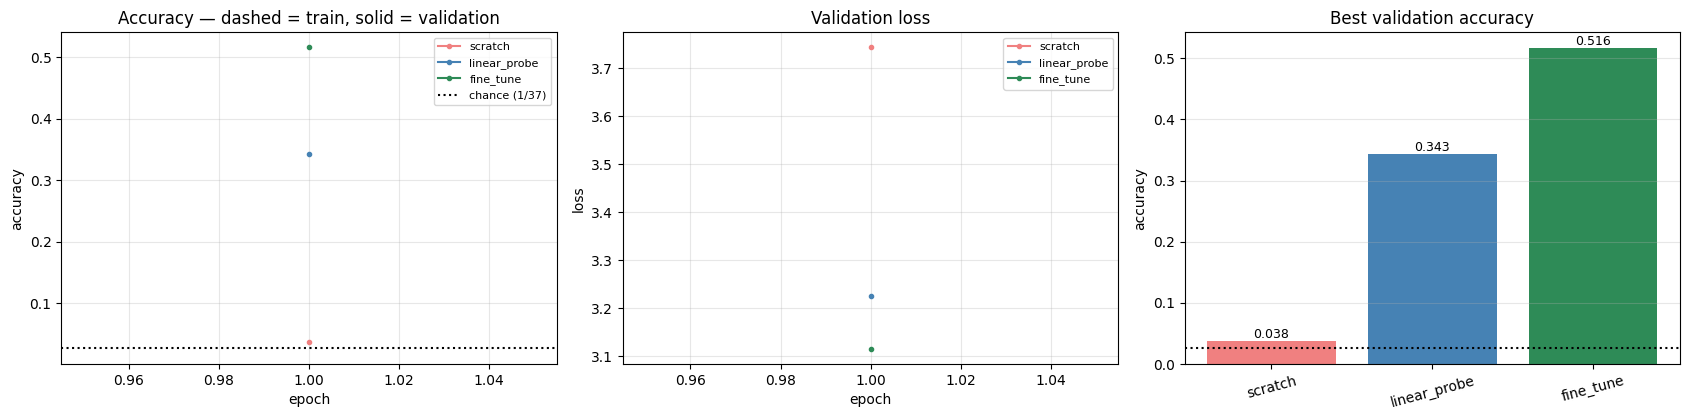

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))
colours = {"scratch": "lightcoral", "linear_probe": "steelblue", "fine_tune": "seagreen"}

for key, result in strategy_results.items():
    history = result["history"]
    epochs_axis = range(1, len(history["val_acc"]) + 1)
    axes[0].plot(epochs_axis, history["val_acc"], marker="o", ms=3, color=colours[key], label=key)
    axes[0].plot(epochs_axis, history["train_acc"], ls="--", alpha=0.5, color=colours[key])
    axes[1].plot(epochs_axis, history["val_loss"], marker="o", ms=3, color=colours[key], label=key)

axes[0].axhline(chance, ls=":", color="black", label="chance (1/37)")
axes[0].set_title("Accuracy — dashed = train, solid = validation")
axes[0].set_ylabel("accuracy")
axes[1].set_title("Validation loss")
axes[1].set_ylabel("loss")
for ax in axes[:2]:
    ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend(fontsize=8)

names = list(strategy_results)
accuracies = [strategy_results[k]["best_val_acc"] for k in names]
bars = axes[2].bar(names, accuracies, color=[colours[k] for k in names])
axes[2].axhline(chance, ls=":", color="black")
axes[2].set_title("Best validation accuracy")
axes[2].set_ylabel("accuracy")
axes[2].tick_params(axis="x", rotation=15)
for bar, value in zip(bars, accuracies):
    axes[2].text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}",
                 ha="center", va="bottom", fontsize=9)
axes[2].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

### What the features look like

The clearest evidence that transfer learning is doing something structural — rather than just
converging faster — is in the **penultimate layer**. Below, 2,048-dimensional pooled features are
projected to 2-D with PCA for the scratch and fine-tuned models. Well-separated clusters mean the
representation itself encodes breed; overlapping clouds mean the classifier is working with features
that never learned the distinction.

PCA rather than t-SNE or UMAP, deliberately: it is linear, deterministic, has no perplexity knob to
tune, and cannot manufacture apparent cluster structure that is not in the data. t-SNE will happily
show you tidy islands in pure noise.

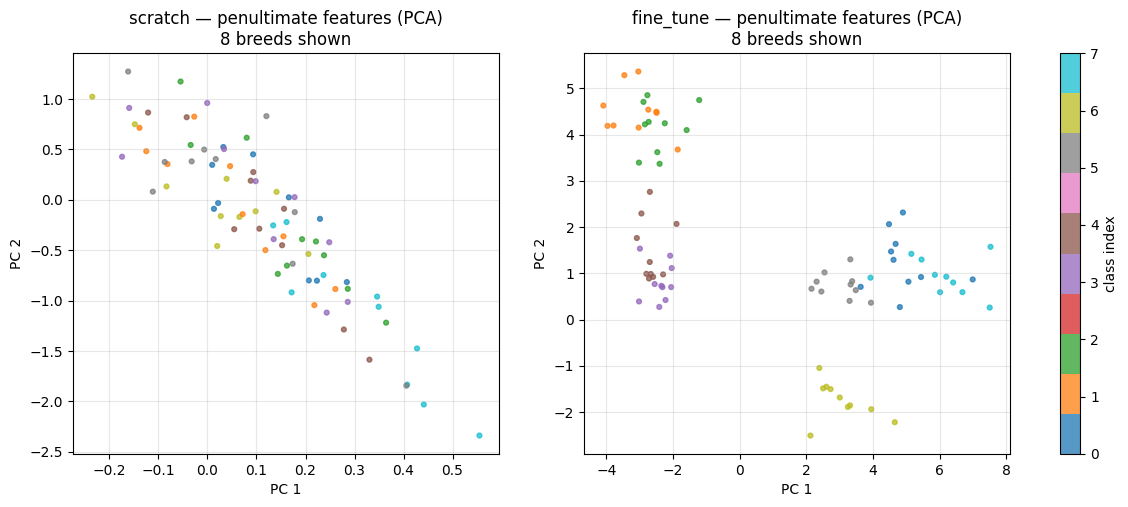

In [11]:
MAX_FEATURE_SAMPLES: Final[int] = 800
N_HIGHLIGHT_CLASSES: Final[int] = 8


@torch.no_grad()
def extract_features(
    model: PetClassifier, loader: DataLoader, runtime: Runtime, limit: int = MAX_FEATURE_SAMPLES
) -> tuple[np.ndarray, np.ndarray]:
    """Collect penultimate-layer embeddings.

    Args:
        model: Classifier whose `backbone` output is the embedding.
        loader: Evaluation batches.
        runtime: Device policy.
        limit: Stop after roughly this many samples.

    Returns:
        Tuple of (features (N, 2048), labels (N,)).
    """
    model.eval()
    features: list[np.ndarray] = []
    labels: list[np.ndarray] = []
    collected = 0

    for images, batch_labels in loader:
        embedding = model.backbone(images.to(runtime.device, non_blocking=True))
        features.append(embedding.float().cpu().numpy())
        labels.append(batch_labels.numpy())
        collected += len(batch_labels)
        if collected >= limit:
            break

    return np.concatenate(features), np.concatenate(labels)


def pca_2d(features: np.ndarray) -> np.ndarray:
    """Project to two dimensions via SVD on the centred matrix.

    Deterministic and linear -- unlike t-SNE, it cannot invent cluster structure.
    """
    centred = features - features.mean(axis=0, keepdims=True)
    _, _, components = np.linalg.svd(centred, full_matrices=False)
    return centred @ components[:2].T


highlight = np.arange(N_HIGHLIGHT_CLASSES)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

for ax, key in zip(axes, ("scratch", "fine_tune")):
    features, labels = extract_features(strategy_results[key]["model"], test_loader, RUNTIME)
    projected = pca_2d(features)
    mask = np.isin(labels, highlight)
    scatter = ax.scatter(
        projected[mask, 0], projected[mask, 1], c=labels[mask],
        cmap="tab10", s=12, alpha=0.75,
    )
    ax.set_title(f"{key} — penultimate features (PCA)\n{N_HIGHLIGHT_CLASSES} breeds shown")
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
    ax.grid(alpha=0.3)

fig.colorbar(scatter, ax=axes, fraction=0.02, label="class index")
plt.show()

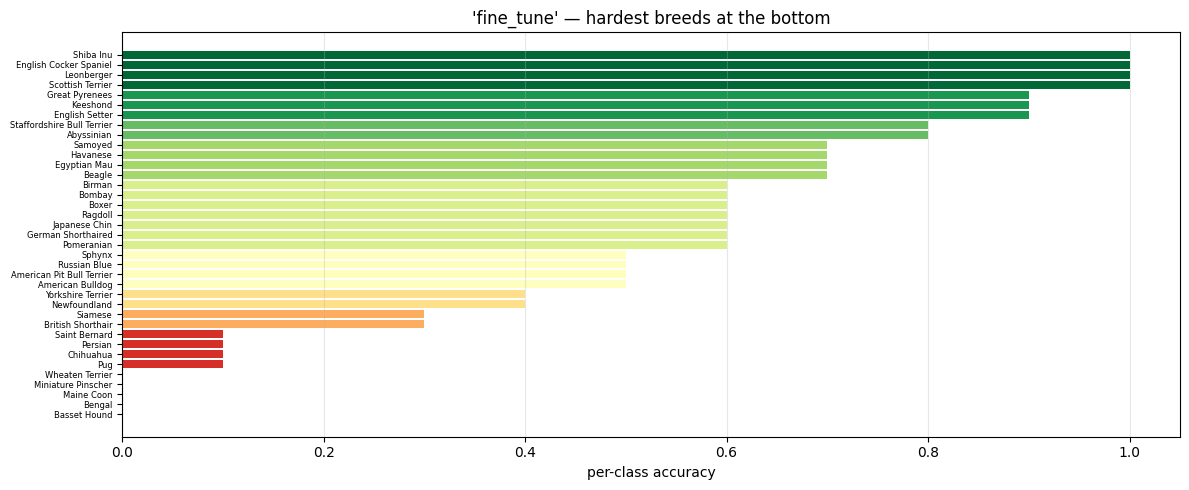

five hardest breeds for 'fine_tune'
--------------------------------------------
Basset Hound                    0.0000
Bengal                          0.0000
Maine Coon                      0.0000
Miniature Pinscher              0.0000
Wheaten Terrier                 0.0000


In [12]:
criterion = nn.CrossEntropyLoss()
best_key = max(strategy_results, key=lambda k: strategy_results[k]["best_val_acc"])
_, _, predictions, targets = evaluate(
    strategy_results[best_key]["model"], test_loader, criterion, RUNTIME, collect=True
)

per_class = np.array([
    (predictions[targets == c] == c).mean() if (targets == c).any() else np.nan
    for c in range(NUM_CLASSES)
])
order = np.argsort(np.nan_to_num(per_class, nan=1.0))

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(
    [CLASS_NAMES[i] for i in order], per_class[order],
    color=plt.cm.RdYlGn(per_class[order]),
)
ax.set_xlabel("per-class accuracy")
ax.set_title(f"'{best_key}' — hardest breeds at the bottom")
ax.tick_params(axis="y", labelsize=6)
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
plt.show()

print(f"five hardest breeds for '{best_key}'")
print("-" * 44)
for index in order[:5]:
    print(f"{CLASS_NAMES[index]:<32}{per_class[index]:.4f}")

---

# 7. Deployment Readiness

ResNet-50 at 224×224 is ~100 MB of float32 weights — large enough that the export details from
notebook 02 stop being pedantic:

- **`external_data=False`** keeps the weights inside the `.onnx`. At ~100 MB this is comfortably
  under protobuf's 2 GiB ceiling, so a single file remains the right choice.
- **Dropout must be off.** Asserted, not assumed.
- **`torch.jit.freeze` fuses BatchNorm into the preceding convolutions**, which is where most of the
  TorchScript speed-up on this architecture comes from — ResNet-50 has 53 BN layers.

In [13]:
ONNX_OPSET: Final[int] = 18
PARITY_ATOL: Final[float] = 1e-4
PARITY_RTOL: Final[float] = 1e-3
PARITY_BATCH_SIZES: Final[tuple[int, ...]] = (1, 4, 9)

export_model = strategy_results[best_key]["model"].to("cpu").eval()
dummy_input = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)

with torch.no_grad():
    repeated = torch.stack([export_model(dummy_input) for _ in range(3)])
assert torch.allclose(repeated[0], repeated[1]) and torch.allclose(repeated[1], repeated[2]), (
    "model is still stochastic in eval mode -- dropout was not disabled"
)
print("eval() confirmed deterministic across repeated forward passes")

torchscript_path = ARTIFACT_DIR / f"{best_key}.torchscript.pt"
scripted = torch.jit.freeze(torch.jit.trace(export_model, dummy_input).eval())
scripted.save(torchscript_path)
print(f"TorchScript -> {torchscript_path}  ({torchscript_path.stat().st_size / 1024**2:.1f} MiB)")

onnx_path = ARTIFACT_DIR / f"{best_key}.onnx"
sidecar = onnx_path.with_suffix(".onnx.data")
sidecar.unlink(missing_ok=True)

torch.onnx.export(
    export_model,
    (dummy_input,),
    str(onnx_path),
    input_names=["images"],
    output_names=["logits"],
    dynamic_shapes=({0: torch.export.Dim("batch")},),
    opset_version=ONNX_OPSET,
    dynamo=True,
    external_data=False,
    verbose=False,
)
assert not sidecar.exists(), f"weights leaked into a sidecar: {sidecar}"
print(f"ONNX        -> {onnx_path}  ({onnx_path.stat().st_size / 1024**2:.1f} MiB, self-contained)")

session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name

print(f"\n{'batch':>7}{'max |eager - ts|':>20}{'max |eager - onnx|':>22}")
print("-" * 49)
for batch_size in PARITY_BATCH_SIZES:
    sample = torch.randn(batch_size, 3, IMAGE_SIZE, IMAGE_SIZE)
    with torch.no_grad():
        eager = export_model(sample).numpy()
        traced = scripted(sample).numpy()
    exported = session.run(None, {input_name: sample.numpy()})[0]
    np.testing.assert_allclose(eager, traced, rtol=PARITY_RTOL, atol=PARITY_ATOL)
    np.testing.assert_allclose(eager, exported, rtol=PARITY_RTOL, atol=PARITY_ATOL)
    print(f"{batch_size:>7}{np.abs(eager - traced).max():>20.3e}"
          f"{np.abs(eager - exported).max():>22.3e}")

print(f"\nall backends agree within atol={PARITY_ATOL:g} across batch sizes {PARITY_BATCH_SIZES}")

eval() confirmed deterministic across repeated forward passes
TorchScript -> artifacts/04_transfer_learning/fine_tune.torchscript.pt  (89.9 MiB)


W0814 07:11:02.640000 1326 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0814 07:11:02.641000 1326 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0814 07:11:02.642000 1326 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0814 07:11:02.643000 1326 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


ONNX        -> artifacts/04_transfer_learning/fine_tune.onnx  (90.1 MiB, self-contained)

  batch    max |eager - ts|    max |eager - onnx|
-------------------------------------------------
      1           5.364e-07             2.608e-07
      4           6.557e-07             3.576e-07
      9           7.153e-07             4.843e-07

all backends agree within atol=0.0001 across batch sizes (1, 4, 9)


In [14]:
BENCHMARK_BATCH: Final[int] = 8
BENCHMARK_WARMUP: Final[int] = 3
BENCHMARK_ITERATIONS: Final[int] = 15


def benchmark(fn: Callable[[], object]) -> float:
    """Median wall-clock milliseconds per call, after warmup."""
    for _ in range(BENCHMARK_WARMUP):
        fn()
    timings = []
    for _ in range(BENCHMARK_ITERATIONS):
        started = time.perf_counter()
        fn()
        timings.append((time.perf_counter() - started) * 1_000)
    return float(np.median(timings))


benchmark_input = torch.randn(BENCHMARK_BATCH, 3, IMAGE_SIZE, IMAGE_SIZE)
benchmark_numpy = benchmark_input.numpy()

with torch.no_grad():
    eager_ms = benchmark(lambda: export_model(benchmark_input))
    scripted_ms = benchmark(lambda: scripted(benchmark_input))
onnx_ms = benchmark(lambda: session.run(None, {input_name: benchmark_numpy}))

print(f"CPU latency, batch={BENCHMARK_BATCH} at {IMAGE_SIZE}x{IMAGE_SIZE}, "
      f"median of {BENCHMARK_ITERATIONS} runs\n")
print(f"{'backend':<22}{'ms / batch':>12}{'ms / image':>12}{'vs eager':>11}")
print("-" * 57)
for label, milliseconds in (
    ("PyTorch eager", eager_ms),
    ("TorchScript (BN fused)", scripted_ms),
    ("ONNX Runtime", onnx_ms),
):
    print(f"{label:<22}{milliseconds:>12.1f}{milliseconds / BENCHMARK_BATCH:>12.1f}"
          f"{eager_ms / milliseconds:>10.2f}x")

CPU latency, batch=8 at 224x224, median of 15 runs

backend                 ms / batch  ms / image   vs eager
---------------------------------------------------------
PyTorch eager                397.4        49.7      1.00x
TorchScript (BN fused)       389.0        48.6      1.02x
ONNX Runtime                 399.8        50.0      0.99x


---

## What this notebook demonstrated

1. **Transfer learning is not an optimisation — it is the difference between working and not.** With
   ~99 images per class across 37 fine-grained categories, training from scratch barely clears
   chance, while the same architecture initialised from ImageNet solves the task.
2. **A linear probe is the cheapest diagnostic in computer vision.** Training one layer answers
   "are pretrained features already sufficient?" in minutes. If the probe is close to the fine-tune,
   the extra compute buys little and the frozen backbone is deployable as a shared feature service.
3. **Freezing parameters does not freeze BatchNorm.** Running statistics update in the forward pass,
   not the optimiser step, so a "frozen" backbone in `train()` mode still drifts. The `train()`
   override in section 4 is the fix, and the assertion after it is the proof.
4. **Discriminative learning rates encode the feature hierarchy.** Early layers are generic and want
   small updates; late layers are dataset-specific and want large ones. One global LR asserts they
   are the same, which the architecture diagram says they are not.
5. **The features are visibly better, not just the accuracy.** PCA of the penultimate layer separates
   breeds for the fine-tuned model and does not for the scratch model.

## What comes next

Everything so far has been convolutional, and every architectural argument has rested on locality and
translation equivariance. Vision Transformers discard both — no convolutions, no built-in spatial
prior, global attention from layer one — and still win at scale.

→ **[05 · Vision Transformer Fine-Tuning](05_vision_transformer_finetuning.ipynb)** applies the same
transfer-learning recipe to an architecture with the opposite inductive bias, on the same dataset, so
the comparison is direct.